# Project 2: Reproducibility in Natural Language Processing



### Read Data

In [4]:
# imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-dark')

In [5]:
# To save our figures
from pathlib import Path
outputs_dir = Path('outputs')

In [6]:
sou = pd.read_csv("data/SOTU.csv")

In [7]:
!pip install spacy
!python -m spacy download en_core_web_sm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.2/33.2 MB 93.8 MB/s eta 0:00:00ta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 875.0/875.0 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 43.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 73.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15/15 [spacy]m14/15 [spacy]]ash]
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 70.4 MB/s eta 0:00:0000:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [8]:
import spacy
from tqdm import tqdm
from collections import Counter

nlp = spacy.load("en_core_web_sm")

## Part 3: Advanced Text Processing - LDA and BERTopic Topic Modeling (20 pts)

**Resources:**
- LDA:
    - https://medium.com/sayahfares19/text-analysis-topic-modelling-with-spacy-gensim-4cd92ef06e06 
    - https://www.kaggle.com/code/faressayah/text-analysis-topic-modeling-with-spacy-gensim#%F0%9F%93%9A-Topic-Modeling (code for previous post)
    - https://towardsdatascience.com/topic-modelling-in-python-with-spacy-and-gensim-dc8f7748bdbf/ 
- BERTopic:
    - https://maartengr.github.io/BERTopic/getting_started/visualization/visualize_documents.html#visualize-documents-with-plotly 
    - https://maartengr.github.io/BERTopic/getting_started/visualization/visualize_topics.html 


In [10]:
from spacy import displacy
#from bertopic import BERTopic
from gensim.corpora import Dictionary
from gensim.models import LdaModel
from sklearn.feature_extraction.text import CountVectorizer
import pyLDAvis
import pyLDAvis.gensim_models

ModuleNotFoundError: No module named 'gensim'

### LDA

- Train an LDA model with 18 topics
- Output the top 10 words for each topic. 
- Output the topic distribution for the first speech
- Make a visualization

You may use the next two cells to process the data.

In [73]:
def preprocess_text(text): 
    doc = nlp(text) 
    return [token.lemma_.lower() for token in doc if not token.is_stop and not token.is_punct and not token.is_space and len(token.lemma_) > 3]

In [74]:
# Process all texts - note this takes ~ 5 minutes to run
processed_docs = sou['Text'].apply(preprocess_text)

To train an LDA model, use the LdaModel function that we imported a couple of cells back. The last resource linked under the LDA section is especially useful for walking through the steps we have below. *Note: one of the arguments to the LdaModel function is `random_state` which specifies the random seed for reproducibility. Please set yours to 42. Further, the last resource provided uses `LdaMulticore` which is essentially a parallelizable version of our function `LdaModel`. Use `LdaModel` instead, but the usage will be similar, except you can ignore the `iterations` and `workers` arguments..*.

In [77]:
# Build dictionary from processed_docs, which is a list of tokens extracted from our speeches

In [78]:
# train LDA model with 18 topics

In [79]:
# print the top 10 words for each topic


--- LDA Topics ---
Topic: 0 
Words: 0.004*"cent" + 0.004*"june" + 0.004*"gold" + 0.003*"island" + 0.003*"silver" + 0.003*"bond" + 0.003*"method" + 0.003*"convention" + 0.003*"indian" + 0.003*"note"

Topic: 1 
Words: 0.008*"depression" + 0.007*"program" + 0.007*"recovery" + 0.006*"budget" + 0.006*"unemployment" + 0.006*"loan" + 0.006*"activity" + 0.006*"farm" + 0.005*"emergency" + 0.005*"cent"

Topic: 2 
Words: 0.008*"dictator" + 0.005*"expression" + 0.004*"british" + 0.004*"1914" + 0.003*"impressive" + 0.003*"actual" + 0.003*"revolution" + 0.003*"schedule" + 0.003*"continent" + 0.003*"partisanship"

Topic: 3 
Words: 0.008*"forest" + 0.007*"corporation" + 0.005*"judge" + 0.005*"wrong" + 0.005*"interstate" + 0.004*"employee" + 0.003*"bureau" + 0.003*"body" + 0.003*"mountain" + 0.003*"island"

Topic: 4 
Words: 0.017*"program" + 0.014*"soviet" + 0.009*"1980" + 0.009*"u.s." + 0.008*"area" + 0.007*"major" + 0.006*"goal" + 0.006*"commitment" + 0.006*"challenge" + 0.006*"nuclear"

Topic: 5 
W

In [83]:
# print the topic distribution for the first speech

[(11, np.float32(0.99942815))]


In [ ]:
# make a visualization using pyLDAvis
pyLDAvis.enable_notebook()
...

### BERTopic

- Train a BERTopic model with a `min_topic_size` of 3 *Hint: use `BERTopic` to instantiate the model and specify `min_topic_size` in here. Actually fit the model using `fit_transform`, which `docs` passed into this.*
- Output the top 10 words for each topic. 
- Output the topic distribution for the first speech
- Make a visualization of the topics (see topic_model.visualize_topics())

In [85]:
docs = sou['Text'].to_list()

In [86]:
# train the model - this takes about 30 seconds

# remove stop words from the topics (Hint: use CountVectorizer and then .update_topics on topic_model)

2025-11-08 22:50:56,658 - BERTopic - Embedding - Transforming documents to embeddings.
Batches: 100%|██████████| 8/8 [00:08<00:00,  1.03s/it]
2025-11-08 22:51:09,053 - BERTopic - Embedding - Completed ✓
2025-11-08 22:51:09,054 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-11-08 22:51:19,326 - BERTopic - Dimensionality - Completed ✓
2025-11-08 22:51:19,327 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-11-08 22:51:19,342 - BERTopic - Cluster - Completed ✓
2025-11-08 22:51:19,346 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-11-08 22:51:20,853 - BERTopic - Representation - Completed ✓


In [87]:
# output the top 10 words for each topic - hint see get_topic_info

,Topic,Count,Name,Representation,Representative_Docs
0,-1,56,-1_states_government_united_congress,"[states, government, united, congress, country...",[\nTo the Congress of the United States:\nYour...
1,0,29,0_world_people_new_years,"[world, people, new, years, america, american,...","[\nMr. Speaker, Mr. President, my colleagues i..."
2,1,18,1_america_americans_american_people,"[america, americans, american, people, tonight...","[\nMr. Speaker, Vice President Cheney, Members..."
3,2,17,2_states_government_united_congress,"[states, government, united, congress, public,...",[\nTo the Senate and House of Representatives ...
4,3,15,3_states_government_united_law,"[states, government, united, law, congress, ye...",[\nTo the Senate and House of Representatives:...
5,4,12,4_government_work_public_congress,"[government, work, public, congress, great, la...",[\nTo the Senate and House of Representatives:...
6,5,11,5_world_peace_nations_soviet,"[world, peace, nations, soviet, nation, econom...","[\nMr. President, Mr. Speaker, Members of the ..."
7,6,9,6_british_states_united_war,"[british, states, united, war, enemy, great, f...",[\nFellow-Citizens of the Senate and House of ...
8,7,8,7_states_government_congress_united,"[states, government, congress, united, year, c...",[\nFellow-Citizens of the Senate and House of ...
9,8,8,8_america_americans_jobs_new,"[america, americans, jobs, new, american, that...","[\nMadam Speaker, Mr. Vice President, Members ..."


100%|██████████| 1/1 [00:14<00:00, 14.91s/it]


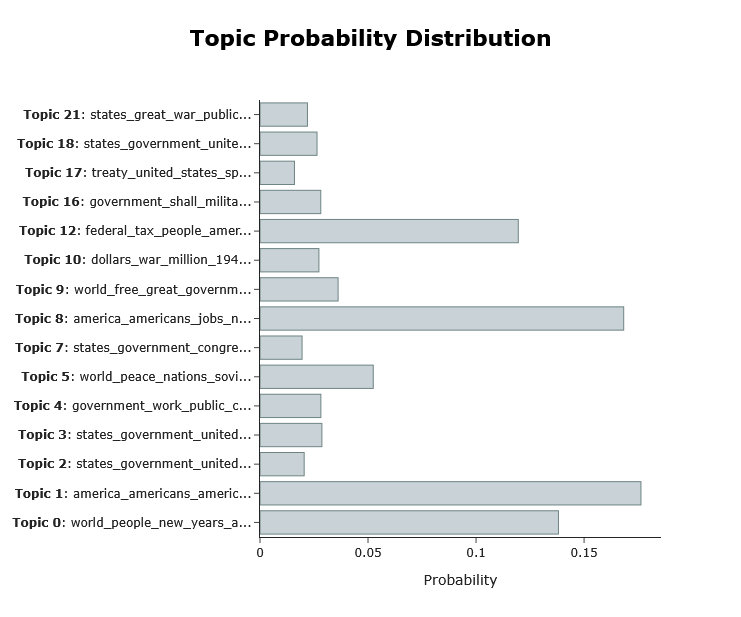

In [88]:
# output the topic distribution for the first speech
# hint: check out approximate_distribution() and visualize_distribution()

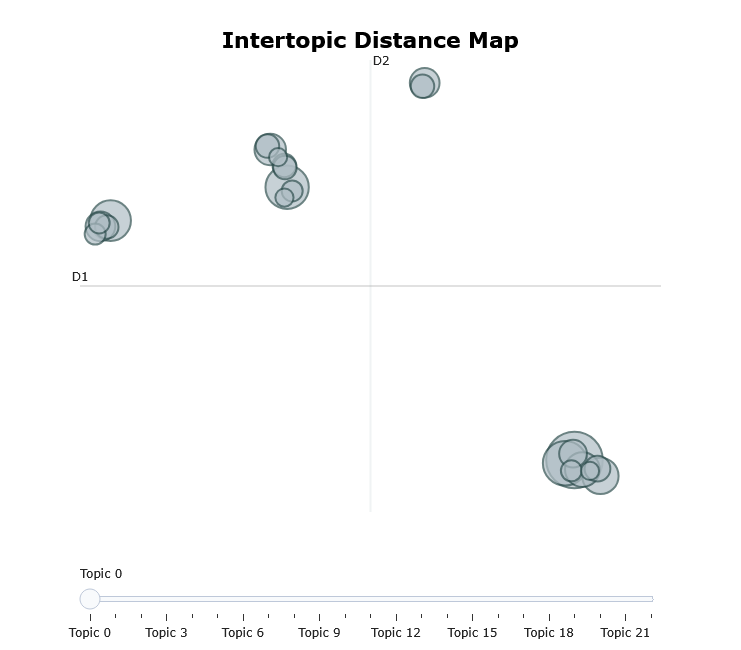

In [90]:
# run this cell to visualize the topics
topic_model.visualize_topics()